# Lab 3: EDA, klasteryzacja i redukcja wymiarów — Football Players

## Cele
- Wykonać EDA na danych piłkarzy
- Przygotować dane do metod nienadzorowanych
- Uruchomić klasteryzację KMeans
- Użyć PCA do wizualizacji klastrów

In [5]:
!pip3 install -r requirements.txt

  Using cached matplotlib-3.10.8-cp314-cp314-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp314-cp314-macosx_10_15_universal2.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pillow-12.2.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp314-cp314-macosx_11_0_arm64.whl (8.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 2.7 MB/s  0:00:03m 2.7 MB/s eta 0:00:01
Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp314-cp314-macosx_10_15_universal2.whl (2.9 MB)
Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11_0_arm64.whl (64 kB)
Usi

In [6]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

## 1. Wczytanie danych

Łączymy profile zawodników ze statystykami po `player_id`.

In [11]:
DATA_DIR = Path("data/13")

profiles_df = pd.read_csv(DATA_DIR / "all_player_profiles.csv")
stats_df = pd.read_csv(DATA_DIR / "all_player_stats.csv")

df = profiles_df.merge(stats_df, on=["player_id", "league"], how="inner")
print(f"Profiles: {len(profiles_df)}, Stats: {len(stats_df)}, Merged: {len(df)}")
df.head()

Profiles: 4740, Stats: 3749, Merged: 3749


,player_id,name,league,position,market_value,appearances,matches_started,minutes_played,goals,assists,expected_goals,expected_assists,rating,total_shots,shots_on_target,yellow_cards,red_cards,tackles,interceptions,saves
0,804508,Viktor Gyökeres,Premier League,F,61000000.0,30,24,1997,12,0,10.3733,1.773005,6.573333,47,18,5,0,6,1,0
1,934235,Bukayo Saka,Premier League,F,126000000.0,27,22,2001,6,3,6.9941,5.761951,7.214815,63,26,1,0,36,14,0
2,794839,Gabriel Jesus,Premier League,F,21000000.0,12,2,320,2,0,1.8434,0.247789,6.541667,15,10,2,0,4,2,0
3,922573,Gabriel Martinelli,Premier League,F,42000000.0,26,10,906,1,3,3.3793,0.999809,6.607692,25,10,2,0,10,0,0
4,836705,Kai Havertz,Premier League,F,48000000.0,7,4,318,0,1,1.2721,0.105223,6.557143,7,1,0,0,5,0,0


## 2. Mini EDA

Sprawdzamy typy kolumn, braki danych i podstawowe rozkłady.

In [12]:
df.info()
df.isna().sum().sort_values(ascending=False)

<class 'pandas.DataFrame'>
RangeIndex: 3749 entries, 0 to 3748
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   player_id         3749 non-null   int64  
 1   name              3749 non-null   str    
 2   league            3749 non-null   str    
 3   position          3749 non-null   str    
 4   market_value      3682 non-null   float64
 5   appearances       3749 non-null   int64  
 6   matches_started   3749 non-null   int64  
 7   minutes_played    3749 non-null   int64  
 8   goals             3749 non-null   int64  
 9   assists           3749 non-null   int64  
 10  expected_goals    3182 non-null   float64
 11  expected_assists  3723 non-null   float64
 12  rating            3749 non-null   float64
 13  total_shots       3749 non-null   int64  
 14  shots_on_target   3749 non-null   int64  
 15  yellow_cards      3749 non-null   int64  
 16  red_cards         3749 non-null   int64  
 17  tackle

expected_goals      567
market_value         67
expected_assists     26
interceptions         0
tackles               0
red_cards             0
yellow_cards          0
shots_on_target       0
total_shots           0
rating                0
player_id             0
name                  0
assists               0
goals                 0
minutes_played        0
matches_started       0
appearances           0
position              0
league                0
saves                 0
dtype: int64

In [13]:
df.describe()

,player_id,market_value,appearances,matches_started,minutes_played,goals,assists,expected_goals,expected_assists,rating,total_shots,shots_on_target,yellow_cards,red_cards,tackles,interceptions,saves
count,3.749000e+03,3.682000e+03,3749.000000,3749.000000,3749.000000,3749.000000,3749.000000,3182.000000,3.723000e+03,3749.000000,3749.000000,3749.000000,3749.000000,3749.000000,3749.000000,3749.000000,3749.000000
mean,9.305713e+05,9.876458e+06,17.716458,12.775407,1149.305682,1.559883,1.097893,1.900095,1.139630e+00,6.712760,14.596959,5.029341,2.255001,0.116564,18.397173,9.673780,3.528674
std,4.638789e+05,1.653617e+07,8.989226,9.368521,795.092890,2.677618,1.690348,2.507885,1.407608e+00,0.662333,16.676500,6.831381,2.159107,0.347295,17.137989,10.314712,15.801667
min,7.910000e+02,2.300000e+04,1.000000,0.000000,1.000000,0.000000,0.000000,0.003200,9.300000e-07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8.018370e+05,1.100000e+06,10.000000,4.000000,452.000000,0.000000,0.000000,0.373650,1.515899e-01,6.600000,3.000000,0.000000,0.000000,0.000000,4.000000,1.000000,0.000000
50%,9.552450e+05,3.600000e+06,20.000000,12.000000,1072.000000,1.000000,0.000000,1.018200,6.547458e-01,6.742308,9.000000,3.000000,2.000000,0.000000,14.000000,6.000000,0.000000
75%,1.131541e+06,1.160000e+07,25.000000,21.000000,1821.000000,2.000000,2.000000,2.287525,1.579777e+00,6.905882,20.000000,7.000000,3.000000,0.000000,29.000000,15.000000,0.000000
max,2.492573e+06,2.180000e+08,32.000000,32.000000,2880.000000,31.000000,18.000000,24.383200,1.481861e+01,9.700000,122.000000,61.000000,12.000000,3.000000,97.000000,63.000000,145.000000


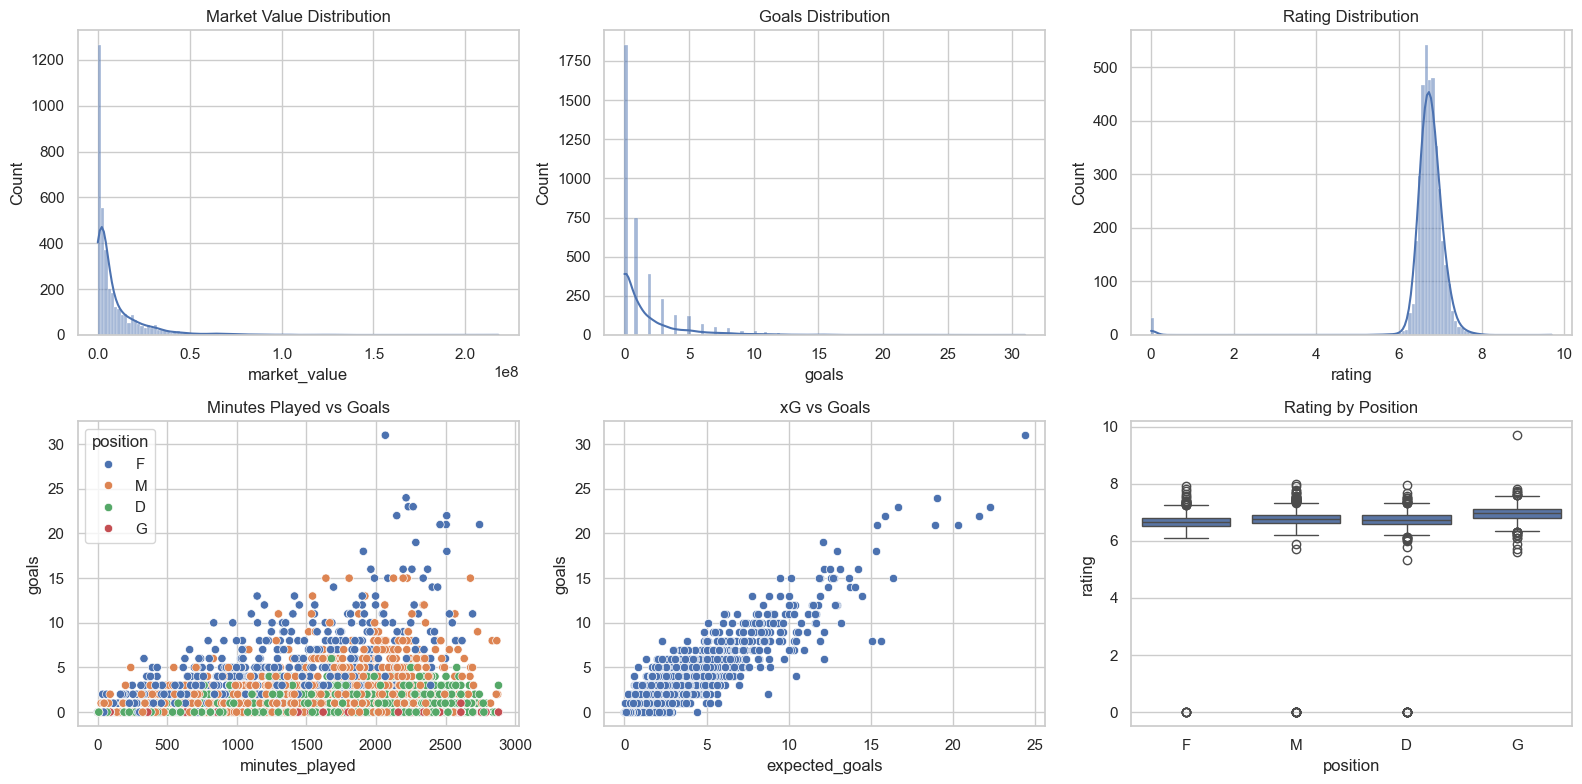

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

sns.histplot(df["market_value"].dropna(), kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Market Value Distribution")

sns.histplot(df["goals"], kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Goals Distribution")

sns.histplot(df["rating"], kde=True, ax=axes[0, 2])
axes[0, 2].set_title("Rating Distribution")

sns.scatterplot(data=df, x="minutes_played", y="goals", hue="position", ax=axes[1, 0])
axes[1, 0].set_title("Minutes Played vs Goals")

sns.scatterplot(data=df, x="expected_goals", y="goals", ax=axes[1, 1])
axes[1, 1].set_title("xG vs Goals")

sns.boxplot(data=df, x="position", y="rating", ax=axes[1, 2])
axes[1, 2].set_title("Rating by Position")

plt.tight_layout()
plt.show()

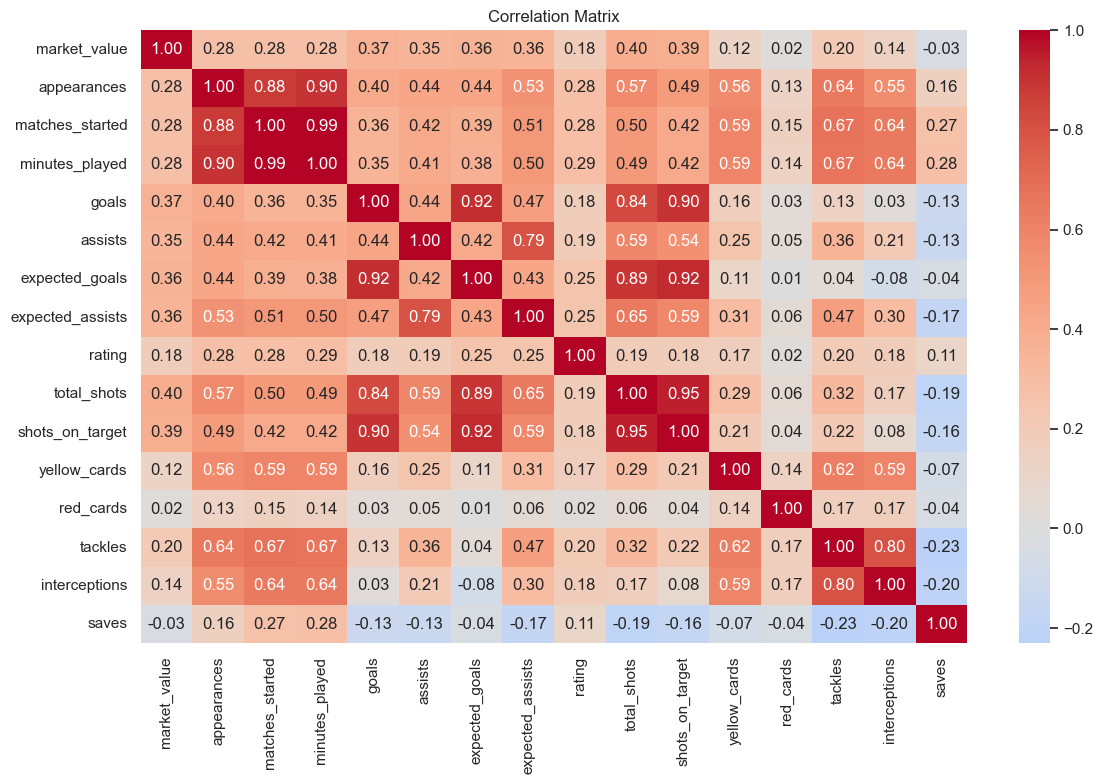

In [15]:
# Correlation heatmap for numeric features
numeric_cols = df.select_dtypes(include="number").columns.drop("player_id")
plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## 3. Przygotowanie cech

Wybieramy cechy numeryczne i kategoryczne istotne dla klasteryzacji. Budujemy pipeline z imputacją, skalowaniem i kodowaniem.

In [16]:
feature_columns = [
    "position", "league",
    "market_value", "appearances", "matches_started", "minutes_played",
    "goals", "assists", "expected_goals", "expected_assists",
    "rating", "total_shots", "shots_on_target",
    "yellow_cards", "red_cards", "tackles", "interceptions", "saves",
]

X = df[feature_columns].copy()

numeric_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = X.select_dtypes(exclude="number").columns.tolist()

print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), categorical_features),
])

X_prepared = preprocessor.fit_transform(X)
print(f"\nShape after preprocessing: {X_prepared.shape}")

Numeric features (16): ['market_value', 'appearances', 'matches_started', 'minutes_played', 'goals', 'assists', 'expected_goals', 'expected_assists', 'rating', 'total_shots', 'shots_on_target', 'yellow_cards', 'red_cards', 'tackles', 'interceptions', 'saves']
Categorical features (2): ['position', 'league']

Shape after preprocessing: (3749, 28)


## 4. Klasteryzacja

### 4a. Dobór liczby klastrów — metoda łokcia + silhouette score

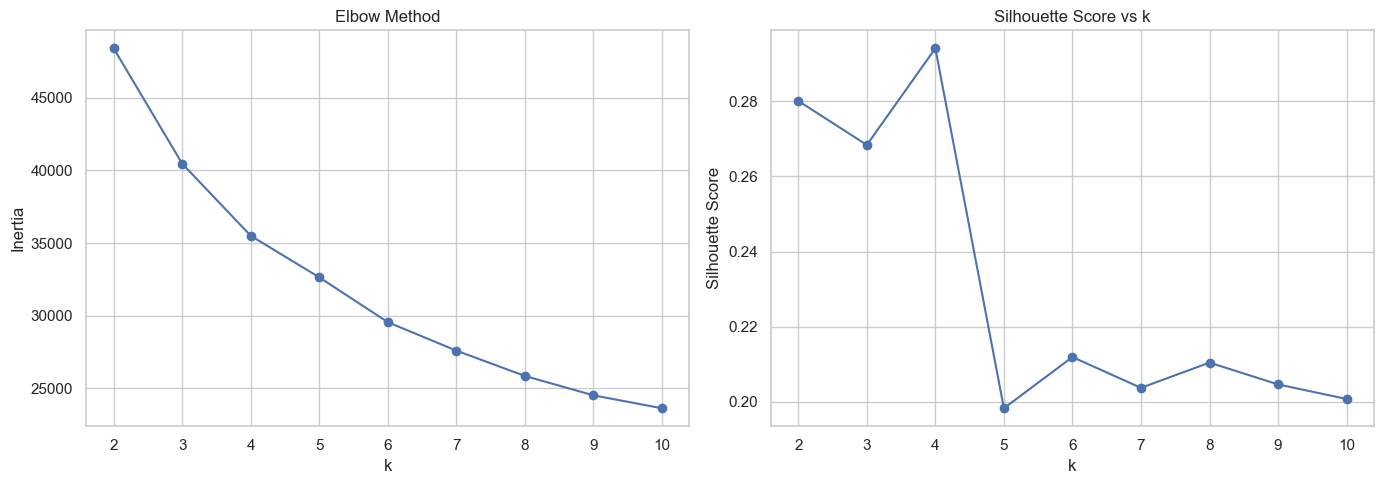

Best k by silhouette: 4 (score=0.2941)


In [17]:
K_range = range(2, 11)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_prepared)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_prepared, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, "o-")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")

axes[1].plot(K_range, silhouettes, "o-")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs k")

plt.tight_layout()
plt.show()

best_k = K_range[np.argmax(silhouettes)]
print(f"Best k by silhouette: {best_k} (score={max(silhouettes):.4f})")

### 4b. KMeans z wybraną liczbą klastrów

In [18]:
N_CLUSTERS = 4

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=20)
clusters = kmeans.fit_predict(X_prepared)

analysis_df = df.copy()
analysis_df["cluster"] = clusters

print("Cluster sizes:")
print(analysis_df.groupby("cluster").size())
print(f"\nSilhouette score: {silhouette_score(X_prepared, clusters):.4f}")

Cluster sizes:
cluster
0     482
1    1256
2    1861
3     150
dtype: int64

Silhouette score: 0.2941


In [ ]:
# Cluster profiles — mean values of key features
cluster_profile = analysis_df.groupby("cluster")[
    ["market_value", "goals", "assists", "rating", "minutes_played",
     "tackles", "interceptions", "saves", "yellow_cards"]
].mean().round(2)
cluster_profile

In [ ]:
# Position distribution per cluster
pd.crosstab(analysis_df["cluster"], analysis_df["position"], normalize="index").round(3)

## 5. PCA — wizualizacja klastrów w 2D

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_prepared)

plot_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": clusters.astype(str),
    "position": df["position"].values,
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="cluster", alpha=0.6, ax=axes[0])
axes[0].set_title("Klastry KMeans po PCA")

sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="position", alpha=0.6, ax=axes[1])
axes[1].set_title("Pozycje zawodników po PCA")

plt.tight_layout()
plt.show()

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.4f}")

## 6. Przykładowi zawodnicy z każdego klastra

In [ ]:
for c in range(N_CLUSTERS):
    subset = analysis_df[analysis_df["cluster"] == c]
    top = subset.nlargest(5, "rating")[["name", "position", "league", "rating", "goals", "assists", "market_value"]]
    print(f"\n--- Cluster {c} (n={len(subset)}) — top 5 by rating ---")
    print(top.to_string(index=False))